In [1]:
from __future__ import annotations

import ast
import json
import zipfile
import os
from pathlib import Path
from typing import Dict, Iterable, List

import pandas as pd

pd.set_option("display.max_colwidth", 120)


def _is_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


IS_COLAB = _is_colab()

# Локальный путь (используется только при запуске НЕ в Colab)
_LOCAL_DATASET = "/Users/slvic/ANYA/22-team-project/DL/artifacts/HDFS_v1"
_LOCAL_OUTPUT  = "/Users/slvic/ANYA/22-team-project/DL/artifacts/logbert"

DATASET_SOURCE = None if IS_COLAB else _LOCAL_DATASET
OUTPUT_DIR     = Path("/content/logbert" if IS_COLAB else _LOCAL_OUTPUT)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Colab       : {IS_COLAB}")
print(f"Dataset src : {DATASET_SOURCE or '(будет задан в следующей ячейке)'}")
print(f"Output dir  : {OUTPUT_DIR}")

Colab       : True
Dataset src : (будет задан в следующей ячейке)
Output dir  : /content/logbert


In [2]:
# Public Google Drive folder download for Colab.
# Скачивает датасет по публичной ссылке и использует /content/hdfs_download как корень.

!pip -q install gdown

from pathlib import Path
import shutil

import gdown

PUBLIC_DRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1s1WEMEgt82KBlaBsokA_PqJ8fnRXcmoo?usp=sharing"
DOWNLOAD_ROOT = Path("/content/hdfs_download")

if DOWNLOAD_ROOT.exists():
    shutil.rmtree(DOWNLOAD_ROOT)
DOWNLOAD_ROOT.mkdir(parents=True, exist_ok=True)

gdown.download_folder(
    url=PUBLIC_DRIVE_FOLDER_URL,
    output=str(DOWNLOAD_ROOT),
    quiet=False,
    remaining_ok=True,
)

required_paths = [
    DOWNLOAD_ROOT / "HDFS.log",
    DOWNLOAD_ROOT / "preprocessed" / "Event_traces.csv",
    DOWNLOAD_ROOT / "preprocessed" / "anomaly_label.csv",
    DOWNLOAD_ROOT / "preprocessed" / "HDFS.log_templates.csv",
]

missing = [str(path) for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError(f"После скачивания не найдены файлы: {missing}")

DATASET_SOURCE = str(DOWNLOAD_ROOT)
print("Будет использован путь:", DATASET_SOURCE)

Retrieving folder contents


Retrieving folder 1zkW7NXtsacpJAroXiPZAr1S5pZxBZ_7p preprocessed
Processing file 1Fu3IsBNVQFrGqep7rAAyrgHhqKVp7Dlp anomaly_label.csv
Processing file 1MOpcy1vuXFr64LZGFECyLeCF7WT3Q_JE Event_occurrence_matrix.csv
Processing file 1iQWRJ4qUt8j7WbgNBNrbWegyNHnbFQ1F Event_traces.csv
Processing file 1htb3lj5jCuKAj9ygOI0uk0fRfe2VhYs4 HDFS.log_templates.csv
Processing file 1atZB9xu3S4IW9uKawaDcv4YbIJLeTlLI HDFS.npz
Processing file 1QT1jD6QpXw6mttkcBVarIYaU7_5CnjCv .DS_Store
Processing file 1mcYUEjE2NAf1rFLzmxXUAFW7NPm2mL1a HDFS.log
Processing file 1CCORg0ab63YsXd-fZDUGc0KRVoqooo_t README.md


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1Fu3IsBNVQFrGqep7rAAyrgHhqKVp7Dlp
To: /content/hdfs_download/preprocessed/anomaly_label.csv
100%|██████████| 18.6M/18.6M [00:00<00:00, 122MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1MOpcy1vuXFr64LZGFECyLeCF7WT3Q_JE
To: /content/hdfs_download/preprocessed/Event_occurrence_matrix.csv
100%|██████████| 53.1M/53.1M [00:00<00:00, 115MB/s] 
Downloading...
From (original): https://drive.google.com/uc?id=1iQWRJ4qUt8j7WbgNBNrbWegyNHnbFQ1F
From (redirected): https://drive.google.com/uc?id=1iQWRJ4qUt8j7WbgNBNrbWegyNHnbFQ1F&confirm=t&uuid=5d37cd48-631c-4e86-85cd-6180d7887af4
To: /content/hdfs_download/preprocessed/Event_traces.csv
100%|██████████| 125M/125M [00:00<00:00, 201MB/s]  
Downloading...
From: https://drive.google.com/uc?id=1htb3lj5jCuKAj9ygOI0uk0fRfe2VhYs4
To: /content/hdfs_download/preprocessed/HDFS.log_templates.csv


Будет использован путь: /content/hdfs_download



Download completed


In [3]:
def candidate_dataset_paths() -> List[Path]:
    cwd = Path.cwd()
    home = Path.home()
    env_paths = []
    for key in ["HDFS_DATASET", "DATASET_SOURCE", "HDFS_V1_PATH"]:
        value = os.environ.get(key)
        if value:
            env_paths.append(Path(value))

    return env_paths + [
        cwd / "HDFS_v1",
        cwd / "HDFS_v1.zip",
        cwd / "data" / "HDFS_v1",
        cwd / "data" / "HDFS_v1.zip",
        home / "Downloads" / "HDFS_v1",
        home / "Downloads" / "HDFS_v1.zip",
        Path("/content/HDFS_v1"),
        Path("/content/HDFS_v1.zip"),
        Path("/content/drive/MyDrive/HDFS_v1"),
        Path("/content/drive/MyDrive/HDFS_v1.zip"),
        Path("/content/drive/MyDrive/datasets/HDFS_v1"),
        Path("/content/drive/MyDrive/datasets/HDFS_v1.zip"),
        Path("/kaggle/input/HDFS_v1"),
        Path("/kaggle/input/HDFS_v1.zip"),
    ]


def resolve_dataset_source(dataset_source: str | Path | None) -> Path:
    if dataset_source is not None:
        path = Path(dataset_source).expanduser()
        if path.exists():
            return path.resolve()
        raise FileNotFoundError(f"Указанный путь не существует: {path}")

    checked = []
    for path in candidate_dataset_paths():
        checked.append(str(path))
        if path.exists():
            return path.resolve()

    checked_text = "\n".join(checked)
    raise FileNotFoundError(
        "Не удалось найти HDFS_v1 автоматически. Проверь путь и задай DATASET_SOURCE вручную.\n"
        f"Проверенные пути:\n{checked_text}"
    )


def ensure_dataset_ready(dataset_source: str | Path | None, extract_root: Path) -> Path:
    dataset_source = resolve_dataset_source(dataset_source)
    extract_root = extract_root.expanduser().resolve()

    if dataset_source.is_dir():
        return dataset_source

    if dataset_source.is_file() and dataset_source.suffix.lower() == ".zip":
        target_dir = extract_root / dataset_source.stem
        target_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(dataset_source) as zf:
            zf.extractall(target_dir)
        return target_dir

    raise FileNotFoundError(f"Путь найден, но это не папка и не zip-архив: {dataset_source}")


def locate_preprocessed_files(dataset_root: Path) -> Dict[str, Path]:
    candidates = {
        "traces": [
            dataset_root / "preprocessed" / "Event_traces.csv",
            dataset_root / "Event_traces.csv",
        ],
        "labels": [
            dataset_root / "preprocessed" / "anomaly_label.csv",
            dataset_root / "anomaly_label.csv",
        ],
        "templates": [
            dataset_root / "preprocessed" / "HDFS.log_templates.csv",
            dataset_root / "HDFS.log_templates.csv",
        ],
    }

    resolved = {}
    for key, paths in candidates.items():
        match = next((path for path in paths if path.exists()), None)
        if match is None:
            raise FileNotFoundError(f"Не найден обязательный файл для '{key}' внутри {dataset_root}")
        resolved[key] = match
    return resolved


def parse_sequence(raw_value: str) -> List[str | float]:
    if isinstance(raw_value, list):
        return raw_value

    text = str(raw_value).strip()
    if not text:
        return []

    try:
        return ast.literal_eval(text)
    except Exception:
        pass

    if text.startswith("[") and text.endswith("]"):
        inner = text[1:-1].strip()
        if not inner:
            return []
        tokens = [item.strip() for item in inner.split(",") if item.strip()]
        parsed: List[str | float] = []
        for token in tokens:
            try:
                parsed.append(float(token))
            except ValueError:
                parsed.append(token)
        return parsed

    raise ValueError(f"Не удалось распарсить последовательность: {raw_value}")


def normalize_binary_label(value: str) -> int:
    value = str(value).strip().lower()
    return 0 if value in {"normal", "success", "0"} else 1


def sequence_to_text(sequence: Iterable[str]) -> str:
    return " ".join(str(item) for item in sequence)


In [4]:
dataset_root = ensure_dataset_ready(DATASET_SOURCE, OUTPUT_DIR / "extracted")
files = locate_preprocessed_files(dataset_root)
files


{'traces': PosixPath('/content/hdfs_download/preprocessed/Event_traces.csv'),
 'labels': PosixPath('/content/hdfs_download/preprocessed/anomaly_label.csv'),
 'templates': PosixPath('/content/hdfs_download/preprocessed/HDFS.log_templates.csv')}

In [5]:
traces_df = pd.read_csv(files["traces"])
labels_df = pd.read_csv(files["labels"])
templates_df = pd.read_csv(files["templates"])

templates_map = dict(zip(templates_df["EventId"], templates_df["EventTemplate"]))
labels_df = labels_df.rename(columns={"Label": "LabelFromAnomalyFile"})

sessions_df = traces_df.merge(labels_df, on="BlockId", how="left")
sessions_df["event_ids"] = sessions_df["Features"].apply(parse_sequence)
sessions_df["time_intervals"] = sessions_df["TimeInterval"].apply(parse_sequence)
sessions_df["event_templates"] = sessions_df["event_ids"].apply(
    lambda seq: [templates_map.get(event_id, event_id) for event_id in seq]
)

sessions_df["session_label"] = sessions_df["LabelFromAnomalyFile"].fillna(sessions_df["Label"])
sessions_df["label_id"] = sessions_df["session_label"].apply(normalize_binary_label)
sessions_df["num_events"] = sessions_df["event_ids"].apply(len)
sessions_df["latency"] = pd.to_numeric(sessions_df["Latency"], errors="coerce")
sessions_df["event_id_text"] = sessions_df["event_ids"].apply(sequence_to_text)
sessions_df["event_template_text"] = sessions_df["event_templates"].apply(sequence_to_text)

sessions_df = sessions_df[
    [
        "BlockId",
        "session_label",
        "label_id",
        "Type",
        "num_events",
        "latency",
        "event_ids",
        "event_templates",
        "time_intervals",
        "event_id_text",
        "event_template_text",
    ]
].rename(columns={"BlockId": "block_id", "Type": "failure_type"})

sessions_df.head()


,block_id,session_label,label_id,failure_type,num_events,latency,event_ids,event_templates,time_intervals,event_id_text,event_template_text
0,blk_-1608999687919862906,Normal,0,NaN,269,3802,"[E5, E22, E5, E5, E11, E11, E9, E9, E11, E9, E26, E26, E26, E6, E5, E16, E6, E5, E18, E25, E26, E26, E3, E25, E6, E6...","[[*]Receiving block[*]src:[*]dest:[*], [*]BLOCK* NameSystem[*]allocateBlock:[*], [*]Receiving block[*]src:[*]dest:[*...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 1.0, ...",E5 E22 E5 E5 E11 E11 E9 E9 E11 E9 E26 E26 E26 E6 E5 E16 E6 E5 E18 E25 E26 E26 E3 E25 E6 E6 E5 E5 E16 E18 E26 E26 E5 ...,[*]Receiving block[*]src:[*]dest:[*] [*]BLOCK* NameSystem[*]allocateBlock:[*] [*]Receiving block[*]src:[*]dest:[*] [...
1,blk_7503483334202473044,Normal,0,NaN,22,3802,"[E5, E5, E22, E5, E11, E9, E11, E9, E11, E9, E26, E26, E26, E3, E2, E2, E23, E23, E23, E21, E21, E21]","[[*]Receiving block[*]src:[*]dest:[*], [*]Receiving block[*]src:[*]dest:[*], [*]BLOCK* NameSystem[*]allocateBlock:[*...","[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.0, 278.0, 442.0, 3044.0, 0.0, 0.0, 31.0, 0.0, 2.0]",E5 E5 E22 E5 E11 E9 E11 E9 E11 E9 E26 E26 E26 E3 E2 E2 E23 E23 E23 E21 E21 E21,[*]Receiving block[*]src:[*]dest:[*] [*]Receiving block[*]src:[*]dest:[*] [*]BLOCK* NameSystem[*]allocateBlock:[*] [...
2,blk_-3544583377289625738,Anomaly,1,21.0,223,3797,"[E5, E22, E5, E5, E11, E9, E11, E9, E11, E9, E3, E26, E26, E26, E3, E3, E3, E3, E3, E3, E3, E3, E3, E3, E3, E3, E3, ...","[[*]Receiving block[*]src:[*]dest:[*], [*]BLOCK* NameSystem[*]allocateBlock:[*], [*]Receiving block[*]src:[*]dest:[*...","[0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",E5 E22 E5 E5 E11 E9 E11 E9 E11 E9 E3 E26 E26 E26 E3 E3 E3 E3 E3 E3 E3 E3 E3 E3 E3 E3 E3 E3 E3 E3 E3 E3 E3 E3 E3 E3 E...,[*]Receiving block[*]src:[*]dest:[*] [*]BLOCK* NameSystem[*]allocateBlock:[*] [*]Receiving block[*]src:[*]dest:[*] [...
3,blk_-9073992586687739851,Normal,0,NaN,22,50448,"[E5, E22, E5, E5, E11, E9, E11, E9, E11, E9, E26, E26, E26, E2, E2, E2, E23, E23, E23, E21, E21, E21]","[[*]Receiving block[*]src:[*]dest:[*], [*]BLOCK* NameSystem[*]allocateBlock:[*], [*]Receiving block[*]src:[*]dest:[*...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 28.0, 188.0, 186.0, 49727.0, 0.0, 0.0, 150.0, 24.0, 144.0]",E5 E22 E5 E5 E11 E9 E11 E9 E11 E9 E26 E26 E26 E2 E2 E2 E23 E23 E23 E21 E21 E21,[*]Receiving block[*]src:[*]dest:[*] [*]BLOCK* NameSystem[*]allocateBlock:[*] [*]Receiving block[*]src:[*]dest:[*] [...
4,blk_7854771516489510256,Normal,0,NaN,38,50583,"[E5, E5, E22, E5, E11, E9, E11, E9, E11, E9, E26, E26, E26, E2, E2, E2, E4, E4, E4, E4, E4, E4, E4, E4, E4, E4, E4, ...","[[*]Receiving block[*]src:[*]dest:[*], [*]Receiving block[*]src:[*]dest:[*], [*]BLOCK* NameSystem[*]allocateBlock:[*...","[0.0, 0.0, 1.0, 48.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 94.0, 285.0, 12.0, 3481.0, 136.0, 2.0, 0.0, 1.0, 1.0, ...",E5 E5 E22 E5 E11 E9 E11 E9 E11 E9 E26 E26 E26 E2 E2 E2 E4 E4 E4 E4 E4 E4 E4 E4 E4 E4 E4 E4 E3 E4 E4 E4 E23 E23 E23 E...,[*]Receiving block[*]src:[*]dest:[*] [*]Receiving block[*]src:[*]dest:[*] [*]BLOCK* NameSystem[*]allocateBlock:[*] [...


In [6]:
summary = {
    "dataset_root": str(dataset_root),
    "num_sessions": int(len(sessions_df)),
    "num_normal": int((sessions_df["label_id"] == 0).sum()),
    "num_anomalies": int((sessions_df["label_id"] == 1).sum()),
    "avg_events_per_session": float(sessions_df["num_events"].mean()),
    "median_events_per_session": float(sessions_df["num_events"].median()),
}
summary


{'dataset_root': '/content/hdfs_download',
 'num_sessions': 575061,
 'num_normal': 558223,
 'num_anomalies': 16838,
 'avg_events_per_session': 19.433814847468355,
 'median_events_per_session': 19.0}

In [7]:
log_path = dataset_root / "HDFS.log"

with log_path.open("r", encoding="utf-8", errors="ignore") as f:
    raw_log_lines = sum(1 for _ in f)

print("Количество строк в HDFS.log:", raw_log_lines)
print("Количество строк в sessions_df:", len(sessions_df))
print("Количество уникальных block_id:", sessions_df["block_id"].nunique())


Количество строк в HDFS.log: 11175629
Количество строк в sessions_df: 575061
Количество уникальных block_id: 575061


In [8]:
csv_output = OUTPUT_DIR / "hdfs_logbert_sessions.csv"
jsonl_output = OUTPUT_DIR / "hdfs_logbert_sessions.jsonl"
events_txt_output = OUTPUT_DIR / "hdfs_logbert_event_ids.txt"
templates_txt_output = OUTPUT_DIR / "hdfs_logbert_templates.txt"
summary_output = OUTPUT_DIR / "hdfs_logbert_summary.json"

sessions_df.to_csv(csv_output, index=False)

with jsonl_output.open("w", encoding="utf-8") as f:
    for row in sessions_df.to_dict(orient="records"):
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

events_txt_output.write_text("\n".join(sessions_df["event_id_text"].tolist()), encoding="utf-8")
templates_txt_output.write_text("\n".join(sessions_df["event_template_text"].tolist()), encoding="utf-8")
summary_output.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Saved CSV: {csv_output}")
print(f"Saved JSONL: {jsonl_output}")
print(f"Saved event-id corpus: {events_txt_output}")
print(f"Saved template corpus: {templates_txt_output}")
print(f"Saved summary: {summary_output}")


Saved CSV: /content/logbert/hdfs_logbert_sessions.csv
Saved JSONL: /content/logbert/hdfs_logbert_sessions.jsonl
Saved event-id corpus: /content/logbert/hdfs_logbert_event_ids.txt
Saved template corpus: /content/logbert/hdfs_logbert_templates.txt
Saved summary: /content/logbert/hdfs_logbert_summary.json


## Для LogBERT обычно используют либо

---

## 2. LogBERT — Log Anomaly Detection via BERT

Реализация по статье: **LogBERT: Log Anomaly Detection via BERT** (Guo et al., 2021).

**Пайплайн:**
1. Словарь строится из уникальных Event ID (e.g. `E5`, `E22`, …).
2. Маленький BERT обучается только на *нормальных* сессиях.
3. Во время обучения используются две self-supervised задачи:
   - **Masked Log Key Prediction**: предсказание случайно замаскированных событий.
   - **Hypersphere / Center objective**: embeddings нормальных последовательностей стягиваются к общему центру в пространстве представлений.
4. На инференсе считаются две аномальные компоненты: MLM-ошибка и расстояние до центра.
5. Итоговый **anomaly score** строится как взвешенная комбинация этих двух компонент.
6. Порог выбирается по 95-му перцентилю скоров нормальных сессий из val-выборки.

In [9]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertConfig,
    BertForMaskedLM,
    get_linear_schedule_with_warmup,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve,
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ── Hyperparameters ──────────────────────────────────────────────────────────
WINDOW_SIZE         = 96     # max tokens per window (including [CLS] / [SEP])
MASK_PROB           = 0.15   # fraction of content tokens masked per sample
HIDDEN_SIZE         = 192
NUM_LAYERS          = 3
NUM_HEADS           = 4
INTERMEDIATE        = 768
EPOCHS              = 5
BATCH_SIZE          = 16
LR                  = 1e-3
WARMUP_RATIO        = 0.05   # fraction of total steps used for linear warm-up
PATIENCE            = 5      # early-stopping patience (epochs without improvement)
TOP_G               = 9      # top-G candidates for anomaly scoring (from paper)
INFER_ROUNDS        = 3      # repeated random-masking rounds during inference
INFER_BATCH         = 64     # batch size for inference forward passes
CENTER_LOSS_WEIGHT  = 0.1    # hypersphere regularization strength
CENTER_WARMUP_EPOCH = 2      # start using center loss after this epoch
MLM_SCORE_WEIGHT    = 0.5
CENTER_SCORE_WEIGHT = 0.5

DEVICE = (
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Device      : {DEVICE}")
print(f"BATCH_SIZE  : {BATCH_SIZE}  |  EPOCHS={EPOCHS}  |  TOP_G={TOP_G}")
print(f"Center loss : {CENTER_LOSS_WEIGHT}  |  start epoch={CENTER_WARMUP_EPOCH}")

Device      : cuda
BATCH_SIZE  : 16  |  EPOCHS=5  |  TOP_G=9
Center loss : 0.1  |  start epoch=2


In [10]:
# ── Special tokens ───────────────────────────────────────────────────────────
PAD_TOKEN, UNK_TOKEN = "[PAD]", "[UNK]"
MASK_TOKEN           = "[MASK]"
DIST_TOKEN, SEP_TOKEN = "[DIST]", "[SEP]"

all_event_ids = sorted({e for seq in sessions_df["event_ids"] for e in seq})
SPECIALS      = [PAD_TOKEN, UNK_TOKEN, MASK_TOKEN, DIST_TOKEN, SEP_TOKEN]
vocab         = SPECIALS + all_event_ids
tok2id        = {t: i for i, t in enumerate(vocab)}
id2tok        = dict(enumerate(vocab))

PAD_ID,  UNK_ID   = tok2id[PAD_TOKEN],  tok2id[UNK_TOKEN]
MASK_ID           = tok2id[MASK_TOKEN]
DIST_ID, SEP_ID   = tok2id[DIST_TOKEN], tok2id[SEP_TOKEN]
N_SPECIAL         = len(SPECIALS)
VOCAB_SIZE        = len(vocab)


def encode_seq(seq):
    """Convert a list of event IDs to token IDs."""
    return [tok2id.get(e, UNK_ID) for e in seq]


print(f"Vocab size  : {VOCAB_SIZE}  (specials={N_SPECIAL}, events={len(all_event_ids)})")
print(f"Event IDs   : {all_event_ids}")
print(f"Sequence token: {DIST_TOKEN}")

Vocab size  : 34  (specials=5, events=29)
Event IDs   : ['E1', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E2', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9']
Sequence token: [DIST]


In [11]:
# ── Train / Val on normal only; Test = normal + all anomaly ──────────────────
normal_seqs  = sessions_df[sessions_df["label_id"] == 0]["event_ids"].tolist()
anomaly_seqs = sessions_df[sessions_df["label_id"] == 1]["event_ids"].tolist()

tr_seqs, tmp      = train_test_split(normal_seqs, test_size=0.20, random_state=SEED)
val_seqs, tn_seqs = train_test_split(tmp,         test_size=0.50, random_state=SEED)

test_seqs = tn_seqs + anomaly_seqs
test_lbls = [0] * len(tn_seqs) + [1] * len(anomaly_seqs)
perm = list(range(len(test_seqs)))
random.Random(SEED).shuffle(perm)
test_seqs = [test_seqs[i] for i in perm]
test_lbls = [test_lbls[i] for i in perm]

# Subsample training set on CPU to keep iteration fast
if DEVICE == "cpu":
    MAX_TRAIN_CPU = 50_000
    tr_seqs = random.sample(tr_seqs, min(MAX_TRAIN_CPU, len(tr_seqs)))
    print(f"CPU mode — training subsample: {len(tr_seqs):,}")

print(f"Train  : {len(tr_seqs):>8,}  normal")
print(f"Val    : {len(val_seqs):>8,}  normal")
print(f"Test   : {len(test_seqs):>8,}  ({len(tn_seqs):,} normal + {len(anomaly_seqs):,} anomaly)")

Train  :  446,578  normal
Val    :   55,822  normal
Test   :   72,661  (55,823 normal + 16,838 anomaly)


In [12]:
class LogBERTDataset(Dataset):
    """
    Sliding-window dataset for LogBERT.
    During MLM training, 15% of content tokens are masked.
    For hypersphere scoring, the same dataset can be used without masking.
    """

    def __init__(self, sequences, window_size=WINDOW_SIZE,
                 mask_prob=MASK_PROB, is_train=True):
        self.window_size = window_size
        self.mask_prob   = mask_prob
        self.is_train    = is_train
        self.max_content = window_size - 2

        self.windows = []
        for seq in sequences:
            enc = encode_seq(seq)
            if not enc:
                continue
            for start in range(0, len(enc), self.max_content):
                self.windows.append(enc[start: start + self.max_content])

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        tokens = self.windows[idx]
        seq    = [DIST_ID] + tokens + [SEP_ID]
        pad    = self.window_size - len(seq)
        attn   = [1] * len(seq) + [0] * pad
        seq    = seq + [PAD_ID] * pad

        inp    = seq[:]
        labels = [-100] * self.window_size

        if self.is_train:
            for i in range(1, len(tokens) + 1):
                if random.random() < self.mask_prob:
                    labels[i] = inp[i]
                    r = random.random()
                    if r < 0.80:
                        inp[i] = MASK_ID
                    elif r < 0.90:
                        inp[i] = random.randint(N_SPECIAL, VOCAB_SIZE - 1)

        return {
            "input_ids":      torch.tensor(inp,    dtype=torch.long),
            "attention_mask": torch.tensor(attn,   dtype=torch.long),
            "labels":         torch.tensor(labels, dtype=torch.long),
        }


train_ds        = LogBERTDataset(tr_seqs,  is_train=True)
val_ds          = LogBERTDataset(val_seqs, is_train=True)
train_embed_ds  = LogBERTDataset(tr_seqs,  is_train=False)
val_embed_ds    = LogBERTDataset(val_seqs, is_train=False)

train_dl = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=(DEVICE == "cuda"),
)
val_dl = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=(DEVICE == "cuda"),
)
train_embed_dl = DataLoader(
    train_embed_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=(DEVICE == "cuda"),
)
val_embed_dl = DataLoader(
    val_embed_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=(DEVICE == "cuda"),
)

print(f"Train windows       : {len(train_ds):,}")
print(f"Val windows         : {len(val_ds):,}")
print(f"Train embed windows : {len(train_embed_ds):,}")
print(f"Val embed windows   : {len(val_embed_ds):,}")

Train windows       : 446,636
Val windows         : 55,830
Train embed windows : 446,636
Val embed windows   : 55,830


In [13]:
def build_sinusoidal_position_embeddings(max_len, dim):
    position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, dim, 2, dtype=torch.float32) * (-np.log(10000.0) / dim))
    pe = torch.zeros(max_len, dim, dtype=torch.float32)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe


bert_cfg = BertConfig(
    vocab_size                   = VOCAB_SIZE,
    hidden_size                  = HIDDEN_SIZE,
    num_hidden_layers            = NUM_LAYERS,
    num_attention_heads          = NUM_HEADS,
    intermediate_size            = INTERMEDIATE,
    max_position_embeddings      = WINDOW_SIZE,
    type_vocab_size              = 1,
    pad_token_id                 = PAD_ID,
    hidden_dropout_prob          = 0.1,
    attention_probs_dropout_prob = 0.1,
    output_hidden_states         = True,
)

model = BertForMaskedLM(bert_cfg).to(DEVICE)

sinusoidal_pe = build_sinusoidal_position_embeddings(WINDOW_SIZE, HIDDEN_SIZE)
with torch.no_grad():
    model.bert.embeddings.position_embeddings.weight.copy_(sinusoidal_pe)
model.bert.embeddings.position_embeddings.weight.requires_grad = False

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model      : LogBERT  ({NUM_LAYERS} layers × {NUM_HEADS} heads, hidden={HIDDEN_SIZE})")
print(f"Parameters : {n_params:,}")
print("Position embeddings: sinusoidal (frozen)")

Model      : LogBERT  (3 layers × 4 heads, hidden=192)
Parameters : 1,379,170
Position embeddings: sinusoidal (frozen)


Epoch   1/5  train_total=0.2264  train_mlm=0.2264  train_center=0.0000  val_total=0.1590
Epoch   2/5  train_total=0.0970  train_mlm=0.0964  train_center=0.0058  val_total=0.0590
Epoch   3/5  train_total=0.0671  train_mlm=0.0671  train_center=0.0007  val_total=0.0525
Epoch   4/5  train_total=0.0562  train_mlm=0.0561  train_center=0.0005  val_total=0.0449
Epoch   5/5  train_total=0.0486  train_mlm=0.0485  train_center=0.0003  val_total=0.0417

Best val loss: 0.0417


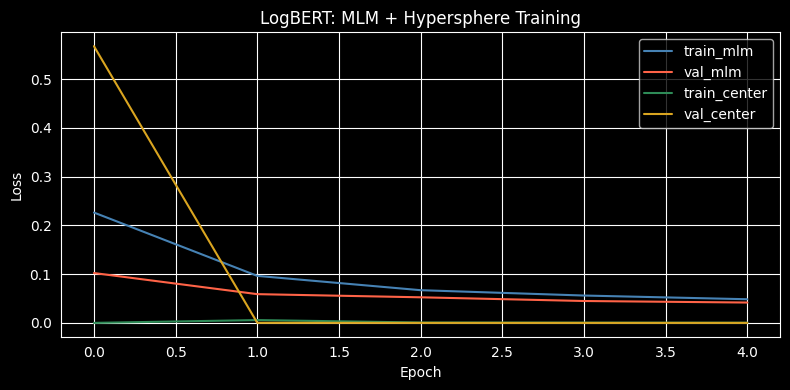

In [14]:


]




optimizer    = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps  = len(train_dl) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)


@torch.no_grad()
def compute_center(data_loader):
    model.eval()
    embeds = []
    for batch in data_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        out = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            output_hidden_states=True,
            return_dict=True,
        )
        dist_emb = F.normalize(out.hidden_states[-1][:, 0, :], dim=1)
        embeds.append(dist_emb)
    center = torch.cat(embeds, dim=0).mean(dim=0)
    return F.normalize(center, dim=0)


@torch.no_grad()
def compute_center_loss(data_loader, center):
    model.eval()
    losses = []
    for batch in data_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        out = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            output_hidden_states=True,
            return_dict=True,
        )
        dist_emb = F.normalize(out.hidden_states[-1][:, 0, :], dim=1)
        losses.append(((dist_emb - center) ** 2).sum(dim=1).mean().item())
    return float(np.mean(losses)) if losses else 0.0


train_losses, val_losses = [], []
train_mlm_losses, val_mlm_losses = [], []
train_center_losses, val_center_losses = [], []
best_val_loss, patience_cnt = float("inf"), 0
center = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    ep_total, ep_mlm, ep_center = 0.0, 0.0, 0.0

    for batch in train_dl:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        out = model(**batch, output_hidden_states=True, return_dict=True)
        mlm_loss = out.loss
        center_loss = torch.tensor(0.0, device=DEVICE)

        if center is not None and epoch >= CENTER_WARMUP_EPOCH:
            dist_emb = F.normalize(out.hidden_states[-1][:, 0, :], dim=1)
            center_loss = ((dist_emb - center) ** 2).sum(dim=1).mean()

        loss = mlm_loss + CENTER_LOSS_WEIGHT * center_loss

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        ep_total += loss.item()
        ep_mlm += mlm_loss.item()
        ep_center += center_loss.item()

    center = compute_center(train_embed_dl)
    train_losses.append(ep_total / len(train_dl))
    train_mlm_losses.append(ep_mlm / len(train_dl))
    train_center_losses.append(ep_center / len(train_dl))

    model.eval()
    vl_total, vl_mlm = 0.0, 0.0
    with torch.no_grad():
        for batch in val_dl:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            out = model(**batch, output_hidden_states=True, return_dict=True)
            vl_mlm += out.loss.item()
            vl_total += out.loss.item()

    val_center = compute_center_loss(val_embed_dl, center)
    val_mlm = vl_mlm / len(val_dl)
    val_total = (vl_total / len(val_dl)) + CENTER_LOSS_WEIGHT * val_center

    val_losses.append(val_total)
    val_mlm_losses.append(val_mlm)
    val_center_losses.append(val_center)

    print(
            f"Epoch {epoch:>3}/{EPOCHS}  "
            f"train_total={train_losses[-1]:.4f}  "
            f"train_mlm={train_mlm_losses[-1]:.4f}  "
            f"train_center={train_center_losses[-1]:.4f}  "
            f"val_total={val_losses[-1]:.4f}"
    )

    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "center": center.detach().cpu(),
            },
            OUTPUT_DIR / "logbert_best.pt",
        )
        patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch}")
            break

checkpoint = torch.load(OUTPUT_DIR / "logbert_best.pt", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
center = checkpoint["center"].to(DEVICE)
print(f"\nBest val loss: {best_val_loss:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_mlm_losses, label="train_mlm", color="steelblue")
ax.plot(val_mlm_losses, label="val_mlm", color="tomato")
ax.plot(train_center_losses, label="train_center", color="seagreen")
ax.plot(val_center_losses, label="val_center", color="goldenrod")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("LogBERT: MLM + Hypersphere Training")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "logbert_training_loss.png", dpi=150)
plt.show()

Scoring validation set…


MLM inference rounds:   0%|          | 0/3 [00:00<?, ?it/s]

/tmp/ipykernel_10209/1788014388.py:49: RuntimeWarning: invalid value encountered in divide
  return np.where(masked > 0, wrong / masked, 0.0)


Anomaly threshold (95th pct of val normals): 0.0037
Scoring test set…


MLM inference rounds:   0%|          | 0/3 [00:00<?, ?it/s]


Metric          Value
----------------------
Precision      0.9757
Recall         0.5219
F1             0.6801
ROC-AUC        0.8637


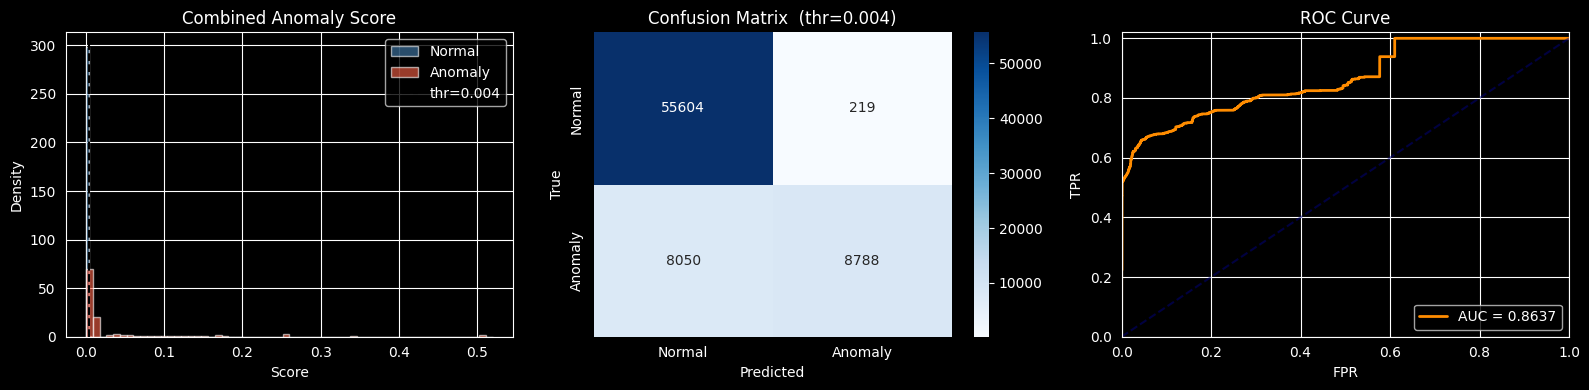


Artifacts saved to: /content/logbert


In [15]:
@torch.no_grad()
def compute_mlm_anomaly_scores(sequences, n_rounds=INFER_ROUNDS,
                               top_g=TOP_G, batch_size=INFER_BATCH):
    model.eval()
    max_content = WINDOW_SIZE - 2

    sess_wins = []
    for seq in sequences:
        enc = encode_seq(seq)
        wins = [enc[s: s + max_content] for s in range(0, max(1, len(enc)), max_content)]
        sess_wins.append(wins)

    wrong = np.zeros(len(sequences), np.int64)
    masked = np.zeros(len(sequences), np.int64)

    for _ in tqdm(range(n_rounds), desc="MLM inference rounds"):
        b_inp, b_attn, b_lbls, b_sidx = [], [], [], []

        for sidx, wins in enumerate(sess_wins):
            for win in wins:
                ids = [DIST_ID] + win + [SEP_ID]
                pad = WINDOW_SIZE - len(ids)
                attn = [1] * len(ids) + [0] * pad
                ids = ids + [PAD_ID] * pad
                inp = ids[:]
                lbls = {}
                for i in range(1, len(win) + 1):
                    if random.random() < MASK_PROB:
                        lbls[i] = inp[i]
                        inp[i] = MASK_ID
                b_inp.append(inp)
                b_attn.append(attn)
                b_lbls.append(lbls)
                b_sidx.append(sidx)

        for start in range(0, len(b_inp), batch_size):
            end = start + batch_size
            inp_t = torch.tensor(b_inp[start:end], dtype=torch.long, device=DEVICE)
            att_t = torch.tensor(b_attn[start:end], dtype=torch.long, device=DEVICE)
            logits = model(input_ids=inp_t, attention_mask=att_t, return_dict=True).logits

            for j, (lbls, sidx) in enumerate(zip(b_lbls[start:end], b_sidx[start:end])):
                for pos, true_id in lbls.items():
                    top_preds = logits[j, pos].topk(top_g).indices.tolist()
                    masked[sidx] += 1
                    if true_id not in top_preds:
                        wrong[sidx] += 1

    return np.where(masked > 0, wrong / masked, 0.0)


@torch.no_grad()
def compute_center_distances(sequences, center, batch_size=INFER_BATCH):
    model.eval()
    max_content = WINDOW_SIZE - 2

    all_inputs, all_attn, all_sidx = [], [], []
    for sidx, seq in enumerate(sequences):
        enc = encode_seq(seq)
        wins = [enc[s: s + max_content] for s in range(0, max(1, len(enc)), max_content)]
        for win in wins:
            ids = [DIST_ID] + win + [SEP_ID]
            pad = WINDOW_SIZE - len(ids)
            attn = [1] * len(ids) + [0] * pad
            ids = ids + [PAD_ID] * pad
            all_inputs.append(ids)
            all_attn.append(attn)
            all_sidx.append(sidx)

    dist_sum = np.zeros(len(sequences), dtype=np.float64)
    dist_cnt = np.zeros(len(sequences), dtype=np.int64)

    for start in range(0, len(all_inputs), batch_size):
        end = start + batch_size
        inp_t = torch.tensor(all_inputs[start:end], dtype=torch.long, device=DEVICE)
        att_t = torch.tensor(all_attn[start:end], dtype=torch.long, device=DEVICE)
        out = model(input_ids=inp_t, attention_mask=att_t, output_hidden_states=True, return_dict=True)
        dist_emb = F.normalize(out.hidden_states[-1][:, 0, :], dim=1)
        dists = ((dist_emb - center) ** 2).sum(dim=1).detach().cpu().numpy()

        for dist, sidx in zip(dists, all_sidx[start:end]):
            dist_sum[sidx] += dist
            dist_cnt[sidx] += 1

    return np.where(dist_cnt > 0, dist_sum / dist_cnt, 0.0)


def minmax_scale(scores):
    scores = np.asarray(scores, dtype=np.float64)
    lo, hi = scores.min(), scores.max()
    if hi - lo < 1e-12:
        return np.zeros_like(scores)
    return (scores - lo) / (hi - lo)


def combine_scores(mlm_scores, center_scores):
    mlm_scaled = minmax_scale(mlm_scores)
    center_scaled = minmax_scale(center_scores)
    combined = MLM_SCORE_WEIGHT * mlm_scaled + CENTER_SCORE_WEIGHT * center_scaled
    return combined, mlm_scaled, center_scaled


print("Scoring validation set…")
val_mlm_scores = compute_mlm_anomaly_scores(val_seqs)
val_center_scores = compute_center_distances(val_seqs, center)
val_scores, val_mlm_scaled, val_center_scaled = combine_scores(val_mlm_scores, val_center_scores)

THRESHOLD = float(np.percentile(val_scores, 95))
print(f"Anomaly threshold (95th pct of val normals): {THRESHOLD:.4f}")

print("Scoring test set…")
test_mlm_scores = compute_mlm_anomaly_scores(test_seqs)
test_center_scores = compute_center_distances(test_seqs, center)
test_scores, test_mlm_scaled, test_center_scaled = combine_scores(test_mlm_scores, test_center_scores)
test_lbls_arr = np.array(test_lbls, dtype=int)
test_preds = (test_scores >= THRESHOLD).astype(int)

prec = precision_score(test_lbls_arr, test_preds, zero_division=0)
rec = recall_score(test_lbls_arr, test_preds)
f1 = f1_score(test_lbls_arr, test_preds)
auc = roc_auc_score(test_lbls_arr, test_scores)

print(f"\n{'Metric':<12} {'Value':>8}")
print("-" * 22)
for name, val in [("Precision", prec), ("Recall", rec), ("F1", f1), ("ROC-AUC", auc)]:
    print(f"{name:<12} {val:>8.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

normal_sc = test_scores[test_lbls_arr == 0]
anomaly_sc = test_scores[test_lbls_arr == 1]
axes[0].hist(normal_sc, bins=60, alpha=0.6, label="Normal", color="steelblue", density=True)
axes[0].hist(anomaly_sc, bins=60, alpha=0.6, label="Anomaly", color="tomato", density=True)
axes[0].axvline(THRESHOLD, color="black", ls="--", label=f"thr={THRESHOLD:.3f}")
axes[0].set_title("Combined Anomaly Score")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Density")
axes[0].legend()

cm = confusion_matrix(test_lbls_arr, test_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"])
axes[1].set_title(f"Confusion Matrix  (thr={THRESHOLD:.3f})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

fpr_arr, tpr_arr, _ = roc_curve(test_lbls_arr, test_scores)
axes[2].plot(fpr_arr, tpr_arr, color="darkorange", lw=2, label=f"AUC = {auc:.4f}")
axes[2].plot([0, 1], [0, 1], color="navy", ls="--", alpha=0.5)
axes[2].set_xlim([0, 1])
axes[2].set_ylim([0, 1.02])
axes[2].set_xlabel("FPR")
axes[2].set_ylabel("TPR")
axes[2].set_title("ROC Curve")
axes[2].legend(loc="lower right")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "logbert_evaluation.png", dpi=150)
plt.show()

np.save(OUTPUT_DIR / "logbert_test_scores.npy", test_scores)
np.save(OUTPUT_DIR / "logbert_test_labels.npy", test_lbls_arr)
np.save(OUTPUT_DIR / "logbert_test_mlm_scores.npy", test_mlm_scores)
np.save(OUTPUT_DIR / "logbert_test_center_scores.npy", test_center_scores)
torch.save(center.detach().cpu(), OUTPUT_DIR / "logbert_center.pt")

results = {
    "threshold": THRESHOLD,
    "precision": round(prec, 4),
    "recall": round(rec, 4),
    "f1": round(f1, 4),
    "roc_auc": round(auc, 4),
    "mlm_score_weight": MLM_SCORE_WEIGHT,
    "center_score_weight": CENTER_SCORE_WEIGHT,
    "center_loss_weight": CENTER_LOSS_WEIGHT,
    "sequence_token": DIST_TOKEN,
    "position_embedding": "sinusoidal_frozen",
}
(OUTPUT_DIR / "logbert_results.json").write_text(
    json.dumps(results, indent=2), encoding="utf-8"
)
print(f"\nArtifacts saved to: {OUTPUT_DIR}")